# Task2 - Graph Mining

This notebook explores graph-based mining on 2025 LoL esports match data. We build a player co-occurrence graph and apply various clustering and embedding methods to uncover underlying league structure.

## Table of Contents

1. [Data Preprocessing](#data-preprocessing)
2. [Data Exploration](#data-exploration)
3. [Graph Construction](#graph-construction)
4. [Graph Clustering](#graph-clustering)
5. [Confusion Matrix Analysis](#confusion-matrix-analysis)
6. [Embedding Deep Dive](#embedding-deep-dive)
7. [Player Similarity](#player-similarity)

In [1]:
# TODO: Add all the installs needed
!pip install ipywidgets scikit-network seaborn --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [3]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


/tmp/ipykernel_43099/4168379563.py:2: DtypeWarning: Columns (0: league) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)
/tmp/ipykernel_43099/4168379563.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")


## Data Preprocessing

Using `smart_drop_na` from the previous checkpoint turned out to drop too many rows, international matches have several columns missing for no apparent reason, which made the resulting graph much less connected. We therefore switched to a more targeted strategy: only entries whose `playerid` is missing are removed.

In [4]:
c2_df = data.drop(data[data["position"] == "team"].index) 

In [5]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
# but there are a few players with missing playerids, we still need to remove these players for our graph mining as we use the playerids to describe the players
missing_playerids = c2_df[c2_df["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
games_with_missing_playerids = c2_df[c2_df["gameid"].isin(missing_playerids["gameid"].unique())] 
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
c2_df = c2_df.drop(games_with_missing_playerids.index)

there are 1803 player performances without an associated playerid and 237 unique player names associated with those performances, we remove all of these


## Data Exploration

Here we examine some simple summary statistics to better understand how to aggregate player stats across leagues.

In [6]:
# For each playerid, print the number of different leagues they played in:
print(c2_df.groupby("playerid")["league"].nunique().value_counts())

league
1    1536
2     653
3     257
4      92
5      27
6       2
Name: count, dtype: int64


In [7]:
# Display some

## Graph Construction

We model the dataset as an undirected graph where nodes are players and an edge connects two players if they appeared in the same match. The result is an unweighted adjacency matrix of shape `(n_players × n_players)`.

In [8]:
uniq_player_ids = c2_df["playerid"].unique()

print("Number of unique player ids:", len(uniq_player_ids))
# Check if uniq_player_ids contains nan
if np.nan in uniq_player_ids:
    print("Warning: uniq_player_ids contains NaN values")
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_index_to_playerid = dict(zip(range(len(uniq_player_ids)), uniq_player_ids))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

Number of unique player ids: 2567


In [9]:
for i in tqdm(range(0, len(c2_df), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(c2_df.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

  0%|          | 0/9691 [00:00<?, ?it/s]

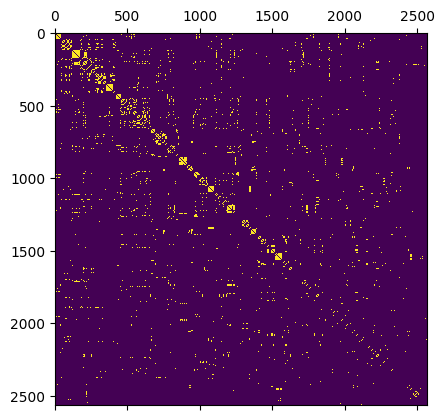

In [10]:
plt.matshow(adj_matrix)

## Graph Clustering

We compare several clustering algorithms and embedding strategies to identify groups of players within the graph.

For each experiment, the number of clusters is set to either **8** (close to both the number of global regions and continents) or **45** (the total number of leagues in the dataset), and we measure how well the clusters align with the true league labels. The evaluation metrics are **Normalized Mutual Information (NMI)** and **Adjusted Rand Index (ARI)**, which are the most robust for this task.

Because many players compete in multiple leagues, some in as many as 6, each player is assigned their most frequent league as a ground-truth label. A perfect score is therefore practically unattainable, but the metrics are still useful for comparing different clustering methods.

  0%|          | 0/6 [00:00<?, ?it/s]

n_clusters = 8, sorted by nmi_regions


,method,n_clusters,nmi_leagues,nmi_regions,nmi_continents,ari_leagues,ari_regions,ari_continents
1,Spectral Embedding + Kmeans (n_clusters = 8),8,0.598929,0.682777,0.651271,0.136162,0.729069,0.652279
4,Spectral Embedding + Gaussian Mixture (n_clust...,8,0.596017,0.669197,0.652397,0.137248,0.715884,0.650001
0,Spectral Clustering (n_clusters = 8),8,0.595369,0.664019,0.643194,0.130634,0.706588,0.644843
3,"Spectral Embedding + OPTICS (min_samples = 5, ...",8,0.567132,0.508496,0.466351,0.150415,0.307877,0.262819
5,Random walk + Kmeans (n_clusters = 8),8,0.661289,0.505089,0.489798,0.291313,0.230710,0.243455
2,"Spectral Embedding + DBSCAN (eps = 0.003, min_...",1247,0.700454,0.367244,0.327012,0.224077,0.015443,0.014833


  0%|          | 0/11 [00:00<?, ?it/s]

/home/vlad/venv/lib/python3.14/site-packages/sklearn/cluster/_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


n_clusters = 45, sorted by nmi_leagues


,method,n_clusters,nmi_leagues,nmi_regions,nmi_continents,ari_leagues,ari_regions,ari_continents
1,Spectral Embedding + Kmeans (n_clusters = 45),45,0.900767,0.555074,0.497866,0.793533,0.094641,0.091189
4,Spectral Embedding + Gaussian Mixture (n_clust...,45,0.899668,0.557317,0.501798,0.794360,0.095196,0.092124
6,Random walk No Jump+ Kmeans (n_clusters = 45),45,0.898909,0.558149,0.501281,0.813472,0.093517,0.089979
0,Spectral Clustering (n_clusters = 45),45,0.894278,0.537605,0.511397,0.767577,0.092047,0.106031
8,Adjacency Based Similarity (Multi-Hop 2) + Kme...,45,0.893867,0.549451,0.495139,0.772119,0.087768,0.084845
7,Adjacency Based Similarity (Adjacency) + Kmean...,45,0.893224,0.548508,0.495007,0.761206,0.084318,0.081623
5,Random walk + Kmeans (n_clusters = 45),45,0.890525,0.552093,0.500144,0.779078,0.088558,0.086552
2,"Spectral Embedding + DBSCAN (eps = 0.003, min_...",1746,0.655750,0.336493,0.299013,0.032965,0.001905,0.001829
9,Adjacency Based Similarity (Laplacian) + Kmean...,45,0.542986,0.300038,0.304967,0.243494,0.031474,0.043132
10,Adjacency Based Similarity (Laplacian Normaliz...,45,0.451044,0.261006,0.245529,0.150217,0.028483,0.032205


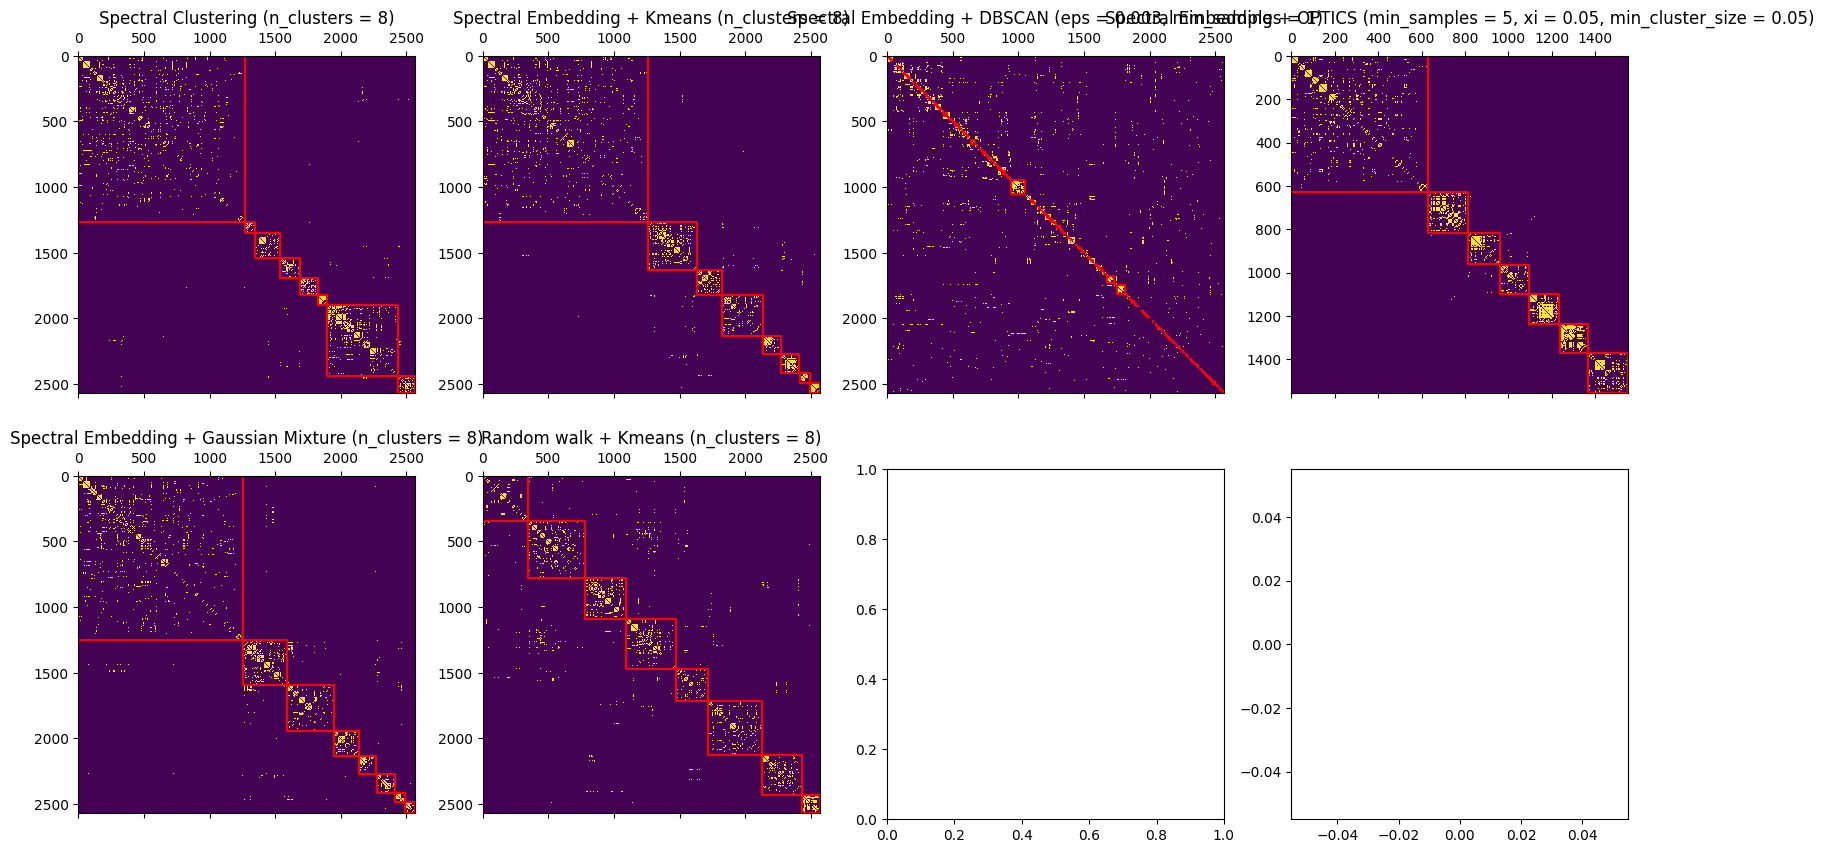

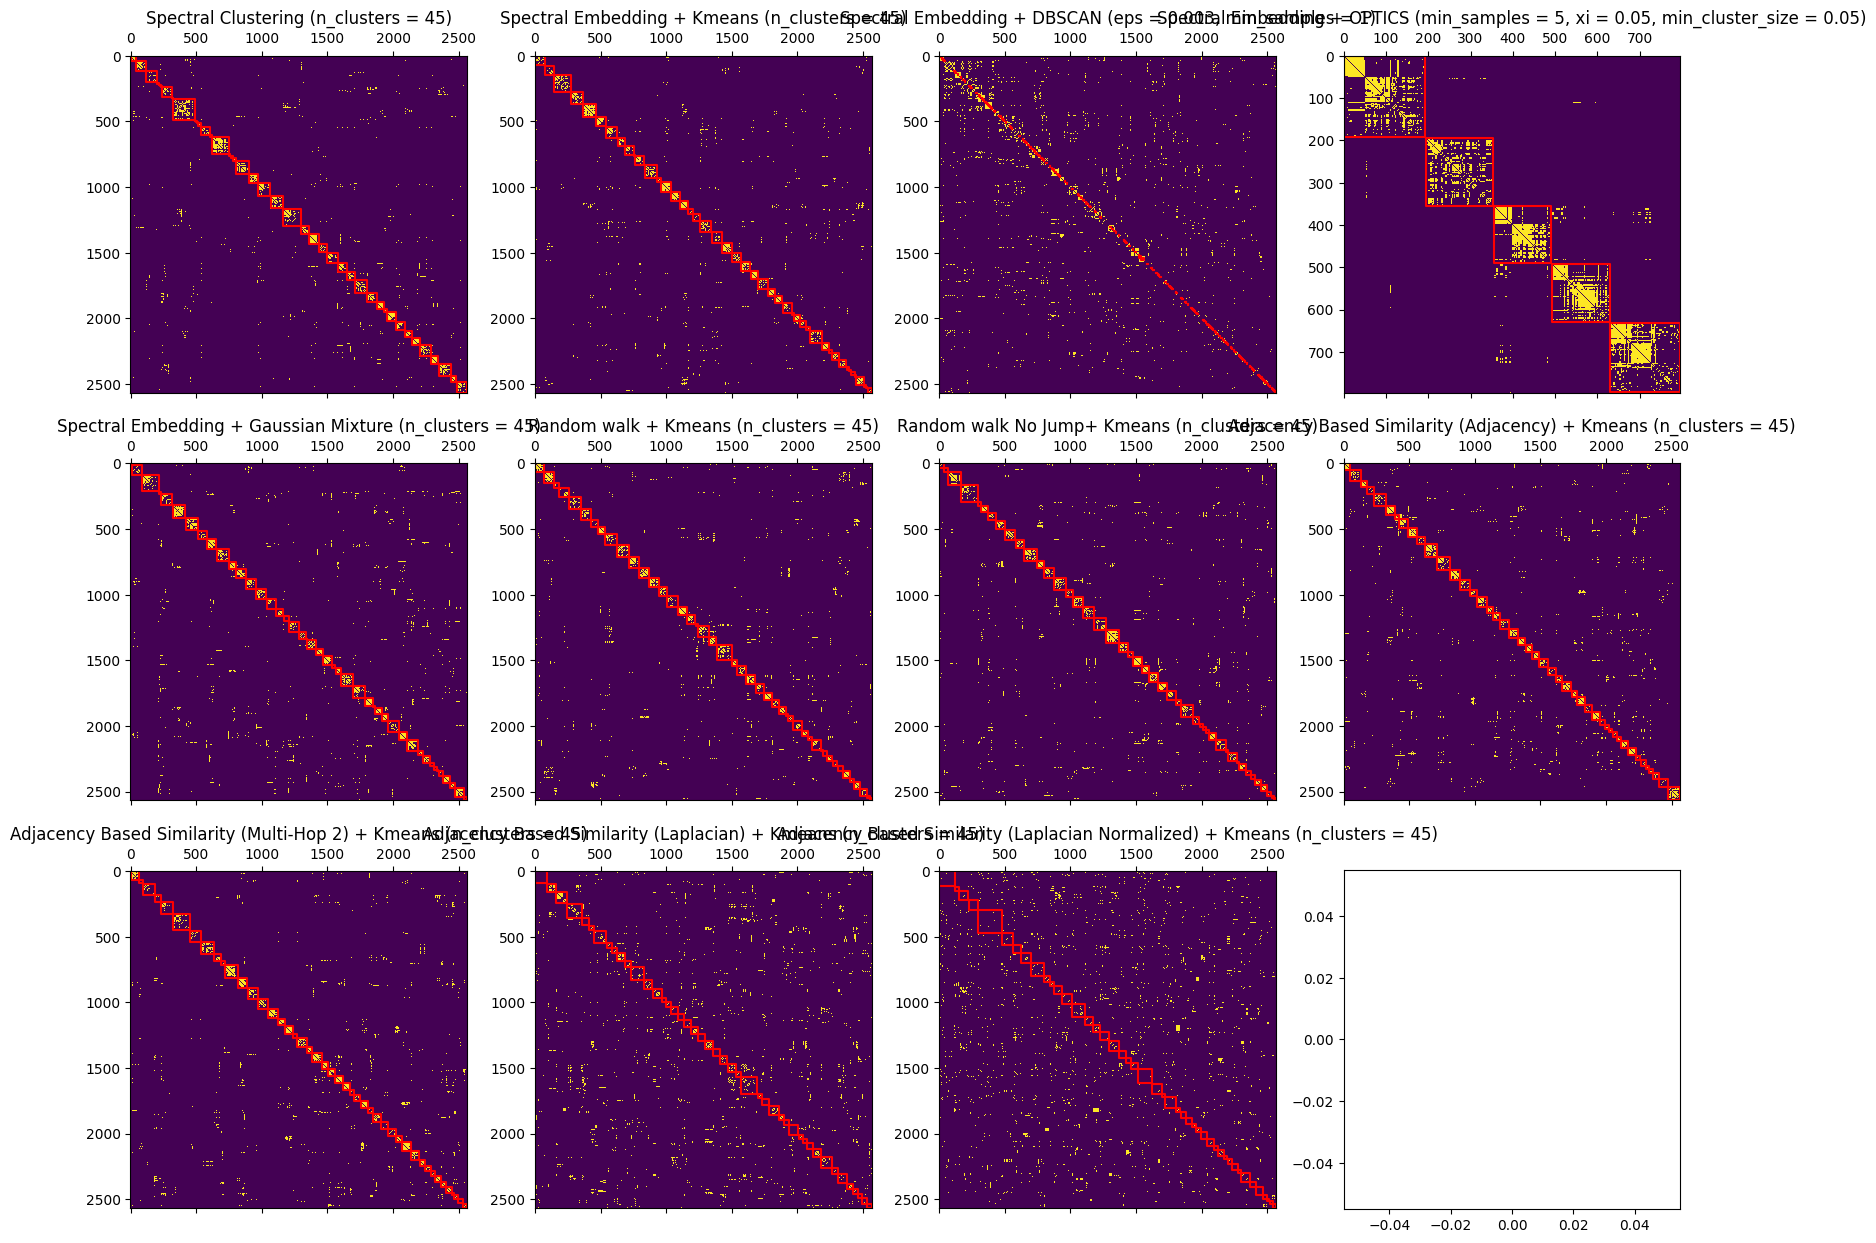

In [11]:
from sknetwork.clustering import Louvain
from sklearn.manifold import SpectralEmbedding, spectral_embedding
from sklearn.cluster import KMeans, DBSCAN, OPTICS, spectral_clustering
from sklearn.mixture import GaussianMixture

from utils.score import compute_all_metrics, score_leagues
from utils.visualize import plot_adj_matrix_sorted_by_clustering
from IPython.display import display

k_means_n_init = 100

embeddings_dir = cwd / "embeddings"

clustering_methods = [
    {
        "type": "direct",
        "name": "Louvain",
        "clustering_algorithm": lambda adj: Louvain().fit_predict(adj)
    },
]

def get_clustering_methods(n_clusters, k_means_n_init=100): 
    clustering_methods = [
    {
        "type": "direct",
        "name": "Spectral Clustering (n_clusters = {n_clusters})",
        "clustering_algorithm": lambda adj: spectral_clustering(adj, n_clusters=n_clusters, n_init=k_means_n_init)
    },
    {
        "type": "embedding",
        "name": "Spectral Embedding + Kmeans (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: spectral_embedding(adj, n_components=n_clusters, random_state=1, drop_first=False),
        "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Spectral Embedding + DBSCAN (eps = 0.003, min_samples = 1)",
        "embedding_algorithm": lambda adj: spectral_embedding(adj, n_components=n_clusters, random_state=1, drop_first=False),
        "clustering_algorithm": lambda embs: DBSCAN(eps=0.003, min_samples=1).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Spectral Embedding + OPTICS (min_samples = 5, xi = 0.05, min_cluster_size = 0.05)",
        "embedding_algorithm": lambda adj: spectral_embedding(adj, n_components=n_clusters, random_state=1, drop_first=False),
        "clustering_algorithm": lambda embs: OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Spectral Embedding + Gaussian Mixture (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: spectral_embedding(adj, n_components=n_clusters, random_state=1, drop_first=False),
        "clustering_algorithm": lambda embs: GaussianMixture(n_components=n_clusters, n_init=1).fit(embs).predict(embs)
    },
    ]
    # Check if the embeddings file exists, if it does not exist, do not add the method to the list of clustering methods
    if (embeddings_dir / f"random_walk_embeddings_dim{n_clusters}_window5_jump0.2.npy").exists():
         clustering_methods.append(
             {
                "type": "embedding",
                "name": "Random walk + Kmeans (n_clusters = {n_clusters})",
                "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"random_walk_embeddings_dim{n_clusters}_window5_jump0.2.npy"),
                "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
            }
        )
    if (embeddings_dir / f"random_walk_embeddings_dim{n_clusters}_window5_jump0.npy").exists():
        clustering_methods.append(
            {
                "type": "embedding",
                "name": "Random walk No Jump+ Kmeans (n_clusters = {n_clusters})",
                "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"random_walk_embeddings_dim{n_clusters}_window5_jump0.npy"),
                "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
            },
        )
    if (embeddings_dir / f"adjacency_similarity_{n_clusters}.npy").exists():
        clustering_methods.append(
            {
                "type": "embedding",
                "name": "Adjacency Based Similarity (Adjacency) + Kmeans (n_clusters = {n_clusters})",
                "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"adjacency_similarity_{n_clusters}.npy"),
                "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
            },
        )
    if (embeddings_dir / f"adjacency_similarity_multihop2_{n_clusters}.npy").exists():
        clustering_methods.append(
            {
                "type": "embedding",
                "name": "Adjacency Based Similarity (Multi-Hop 2) + Kmeans (n_clusters = {n_clusters})",
                "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"adjacency_similarity_multihop2_{n_clusters}.npy"),
                "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
            },
        )
    if (embeddings_dir / f"adjacency_similarity_laplacian_{n_clusters}.npy").exists():
        clustering_methods.append(
            {
                "type": "embedding",
                "name": "Adjacency Based Similarity (Laplacian) + Kmeans (n_clusters = {n_clusters})",
                "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"adjacency_similarity_laplacian_{n_clusters}.npy"),
                "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
            },
        )
    if (embeddings_dir / f"adjacency_similarity_laplacian_normalized_{n_clusters}.npy").exists():
        clustering_methods.append(
            {
                "type": "embedding",
                "name": "Adjacency Based Similarity (Laplacian Normalized) + Kmeans (n_clusters = {n_clusters})",
                "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"adjacency_similarity_laplacian_normalized_{n_clusters}.npy"),
                "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
            },
        )
    return clustering_methods

for n_clusters in [8, 45]:
    if n_clusters != 0:
        clustering_methods = get_clustering_methods(n_clusters, k_means_n_init)

    num_clustering_methods = len(clustering_methods)
    ncols = min(num_clustering_methods, 4)
    nrows = num_clustering_methods // ncols + int(num_clustering_methods % ncols > 0)
    # Create axis
    _, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    method_results = []
    for i, method in tqdm(enumerate(clustering_methods), total=len(clustering_methods)):
        if method["type"] == "direct":
            labels = method["clustering_algorithm"](adj_matrix)
        elif method["type"] == "embedding":
            embs = method["embedding_algorithm"](adj_matrix)
            # embs = embs - np.mean(embs, axis=0, keepdims=True)
            # embs = embs / np.std(embs, axis=0, keepdims=True)
            embs = embs / np.linalg.norm(embs, axis=1, keepdims=True)
            labels = method["clustering_algorithm"](embs)
        
        metrics = compute_all_metrics(labels, uniq_player_ids, c2_df)
        method_results.append({
            "method": method["name"].format(n_clusters=n_clusters),
            "n_clusters": len(set(labels)),
            **metrics
        })
        if nrows > 1:
            ax = axes[i // ncols][i % ncols]
        else:
            ax = axes[i % ncols]
        ax.set_title(method["name"].format(n_clusters=n_clusters))
        plot_adj_matrix_sorted_by_clustering(adj_matrix, labels, ax=ax)
    plt.plot()


    method_results_df = pd.DataFrame(method_results)
    if n_clusters == 8:
        print("n_clusters = 8, sorted by nmi_regions")
        display(method_results_df.sort_values("nmi_regions", ascending=False))
    elif n_clusters == 45:
        print("n_clusters = 45, sorted by nmi_leagues")
        display(method_results_df.sort_values("nmi_leagues", ascending=False))

## Confusion Matrix Analysis

Since we don't know exactly what each cluster represents in the different methods, we map each cluster to the league most commonly represented by its members (via `.mode()`). This is not a perfect approach, but it is a reasonable approximation when the clustering is sufficiently pure.

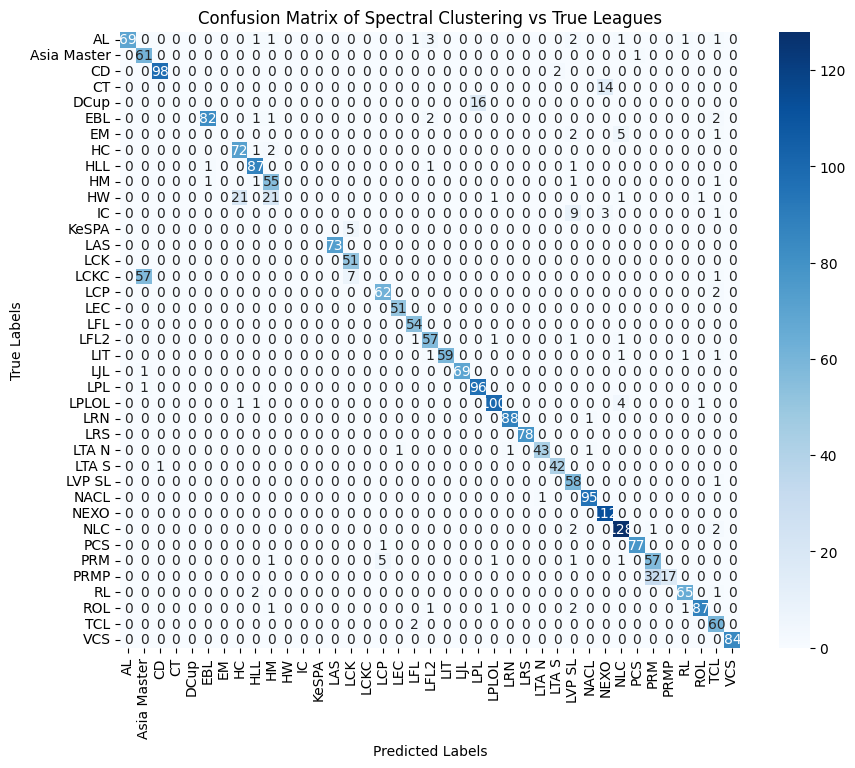

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

true_labels = c2_df.groupby("playerid")["league"].agg(lambda x: x.mode()[0]).loc[uniq_player_ids].values

clustering = spectral_clustering(adj_matrix, n_clusters=n_clusters, n_init=k_means_n_init)
#player_ids_cluster_0 = [adj_index_to_playerid[idx] for idx in np.where(clustering == 0)[0]]
#print(f"Players in cluster 0: {player_ids_cluster_0}")
#leagues_cluster_0 = c2_df[c2_df["playerid"].isin(player_ids_cluster_0)].groupby("playerid")["league"].agg(lambda x: x.mode()[0])
#print(f"Leagues of players in cluster 0: {leagues_cluster_0.value_counts()}")
pred_labels = np.empty_like(clustering, dtype=object)
for cluster in np.unique(clustering):
    cluster_indices = np.where(clustering == cluster)[0]
    cluster_player_ids = [adj_index_to_playerid[idx] for idx in cluster_indices]
    cluster_leagues = c2_df[c2_df["playerid"].isin(cluster_player_ids)].groupby("playerid")["league"].agg(lambda x: x.mode()[0])
    most_common_league = cluster_leagues.mode()[0]
    pred_labels[cluster_indices] = most_common_league

# print(pred_labels[:10])
# print(true_labels[:10])

# print("Predicted label distribution:")
# print(pd.Series(pred_labels).value_counts())
# print("\nTrue label distribution:")
# print(pd.Series(true_labels).value_counts())

labels = sorted(np.unique(np.concatenate((true_labels, pred_labels))))

cm = confusion_matrix(true_labels, pred_labels, labels=labels)
# print(labels[:10])
# print(cm[:10, :10])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Spectral Clustering vs True Leagues')
plt.show()

The confusion matrix is noticeably diagonal, indicating that the clusters broadly correspond to real leagues.

It is not surprising that smaller leagues such as NEXO and NLC appear to "own" the most players — the `.mode()` assignment can attract players from larger adjacent leagues into these smaller buckets.

**Notable misclassifications:**
- **PRMP missclassified as PRM**: expected, as PRMP is a sub-league of PRM and the two rosters overlap heavily.
- **LCKC missclassified as Asia Masters**: also expected — LCKC is Korea's second-tier league, and Asia Masters draws top teams from across Asia, so the player pools share significant overlap.

## Embedding Deep Dive

Here we take a closer look at an interesting embedding we found: **Adjacency-Based Similarity**. When we don't normalize them, there is one big cluster as well as 44 other smaller clusters. Because we cluster using the KMeans algorithm which is not designed for density imbalance, we make the assumtion that it will cluster the low number of neighbors in the big cluster together, and then split the rest of the players into the remaining 44 clusters. Before exploring this, we created a drawing with how we hypothesize the data would be distributed before and after the normalization.

![Different normalizations](assets/different_normalizations_adj_matrix_embeddings.png)

In [13]:
from sknetwork.clustering import Louvain
from sklearn.manifold import SpectralEmbedding, spectral_embedding
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.metrics import normalized_mutual_info_score

n_clusters = 45

## Simple clustering on adj matrix
#clustering = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=n_clusters)
#clustering = Louvain().fit_predict(adj_matrix)

# Embedding then clustering
#embs = SpectralEmbedding(n_components=32).fit_transform(adj_matrix)
#embs = spectral_embedding(adj_matrix, n_components=n_clusters, random_state=1, drop_first=False)

#embs = np.load(embeddings_dir / "random_walk_embeddings_dim45_window5_jump0.2.npy")
#embs = np.load(cwd / "adjacency_similarity_multihop2_45.npy")
embs = np.load(embeddings_dir / "adjacency_similarity_45.npy")
print(embs.shape)
#embs = embs / np.linalg.norm(embs, axis=1, keepdims=True)
clustering = KMeans(n_clusters=n_clusters, n_init=10).fit(embs).labels_

#clustering = DBSCAN(eps=0.003, min_samples=1).fit(embs).labels_
#clustering = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05).fit(embs).labels_
#clustering = GaussianMixture(n_components=n_clusters, n_init=1).fit(embs).predict(embs)

nmi_leagues = score_leagues(clustering, uniq_player_ids, data, normalized_mutual_info_score)
print(nmi_leagues)

(2567, 45)
0.7507860588249369


{'ari_continents': 0.046443918177438384,
 'ari_leagues': 0.2715498913160351,
 'ari_regions': 0.054826481377598026,
 'nmi_continents': 0.40575608339403185,
 'nmi_leagues': 0.7509602608820259,
 'nmi_regions': 0.46242278913660745}
silhouette_score between embeddings and clustering (more of a metric of the clustering aglorithm on top of embs): 0.44749730825424194


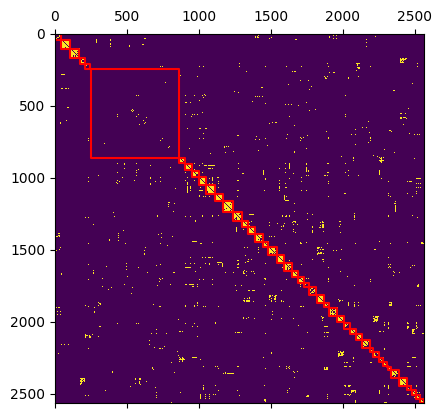

In [14]:
from utils.visualize import plot_adj_matrix_sorted_by_clustering
from sklearn.metrics import silhouette_score

plot_adj_matrix_sorted_by_clustering(adj_matrix, clustering)

metrics = compute_all_metrics(clustering, uniq_player_ids, c2_df)

from pprint import pprint
pprint(metrics)

silhouette_score_value = silhouette_score(embs, clustering)
print("silhouette_score between embeddings and clustering (more of a metric of the clustering aglorithm on top of embs):", silhouette_score_value)

In [15]:
#embs = np.load(embeddings_dir / "adjacency_similarity_45.npy")
embs = spectral_embedding(adj_matrix, n_components=n_clusters, random_state=1, drop_first=False)
print("std and mean of spectral_embeddings: ", np.linalg.norm(embs, axis=1).std(), np.linalg.norm(embs, axis=1).mean())
# Max embedding norm
#print(np.mean(embs[0]))
#print(np.linalg.norm(embs[0]))
#print(np.linalg.norm(embs, axis=1).max())
#print(np.linalg.norm(embs, axis=1).min())
embs = np.load(embeddings_dir / "adjacency_similarity_45.npy")
print("std and mean of adjacency_similarity_45: ", np.linalg.norm(embs, axis=1).std(), np.linalg.norm(embs, axis=1).mean())

clustering = KMeans(n_clusters=n_clusters, n_init=10).fit(embs).labels_

unique_labels, counts = np.unique(clustering, return_counts=True)
biggest_cluster = unique_labels[np.argmax(counts)]
biggest_cluster_mean_norm = np.mean(np.linalg.norm(embs[clustering == biggest_cluster], axis=1))
not_in_biggest_cluster_mean_norm = np.mean(np.linalg.norm(embs[clustering != biggest_cluster], axis=1))

print(biggest_cluster_mean_norm, not_in_biggest_cluster_mean_norm)

std and mean of spectral_embeddings:  0.01663529328009647 0.02014781550137026
std and mean of adjacency_similarity_45:  0.35943198 0.7867999
0.24679102 0.9609604


In [16]:
# Indexes in the biggest cluster
biggest_cluster_indexes = np.where(clustering == biggest_cluster)[0]
biggest_cluster_playerids = [adj_index_to_playerid[idx] for idx in biggest_cluster_indexes]

# Number of games for each player
biggest_cluster_num_games = c2_df[c2_df["playerid"].isin(biggest_cluster_playerids)].groupby("playerid").size()
print(biggest_cluster_num_games.describe())

# Number of games for all the other players
not_in_biggest_cluster_num_games = c2_df[~c2_df["playerid"].isin(biggest_cluster_playerids)].groupby("playerid").size()
print(not_in_biggest_cluster_num_games.describe())



count    626.000000
mean       5.388179
std        4.447862
min        1.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       29.000000
dtype: float64
count    1941.000000
mean       48.190108
std        37.801931
min         2.000000
25%        18.000000
50%        39.000000
75%        65.000000
max       200.000000
dtype: float64


/tmp/ipykernel_43099/1530776997.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_labels = plt.cm.get_cmap('turbo', len(np.unique(clustering)))(clustering)


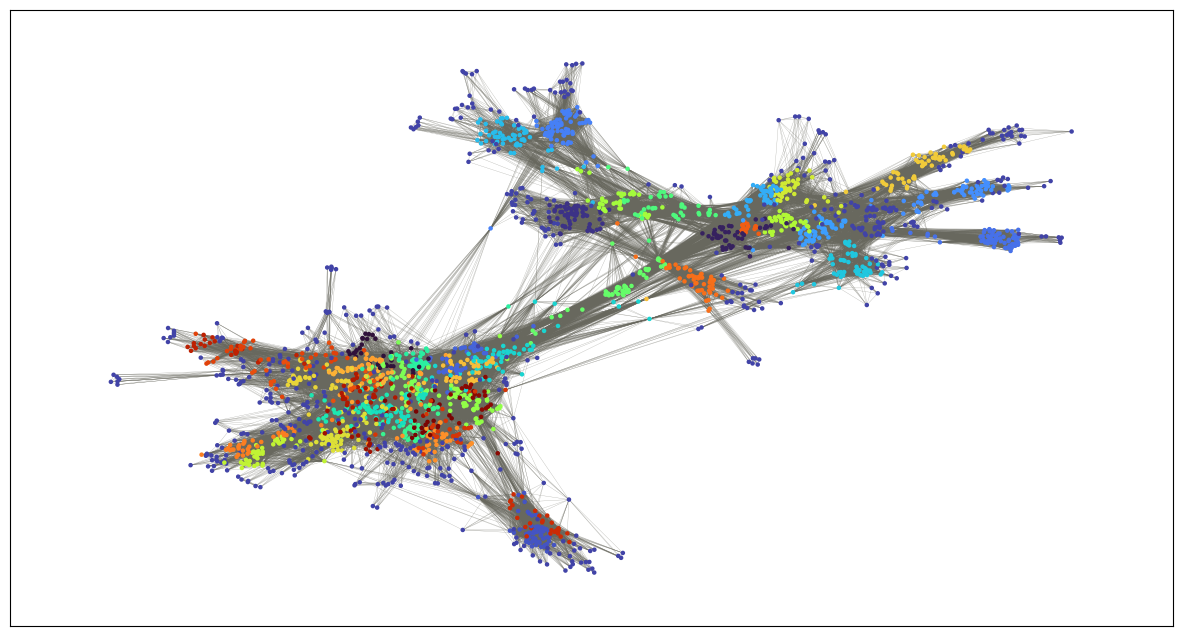

In [17]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
color_labels = plt.cm.get_cmap('turbo', len(np.unique(clustering)))(clustering)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

## Player Similarity

Using the random-walk embeddings, we can compute cosine similarity between players to retrieve the most similar nodes. As a sanity check, we look up the 10 players most similar to **Faker**, T1's mid-laner and one of the most decorated players in LoL history.

In [18]:
embs = np.load(embeddings_dir / f"random_walk_embeddings_dim{n_clusters}_window5_jump0.2.npy")
embs /= np.linalg.norm(embs, axis=1, keepdims=True)
faker_embed = embs[247]
embs_sim = embs @ faker_embed
embs_sim_argsort = np.argsort(embs_sim)[::-1]
print(embs_sim_argsort[:10])
second_player_id = adj_index_to_playerid[embs_sim_argsort[1]]
embs_sim_argsort_playerids = [adj_index_to_playerid[idx] for idx in embs_sim_argsort[:10]]
embs_sim_argsort_playernames = [c2_df[c2_df["playerid"] == player_id]["playername"].unique() for player_id in embs_sim_argsort_playerids]
print(embs_sim_argsort_playernames)

[247 246 249 245 286 176 193 170 284 281]
[<StringArray>
['Faker']
Length: 1, dtype: str, <StringArray>
['Oner']
Length: 1, dtype: str, <StringArray>
['Keria']
Length: 1, dtype: str, <StringArray>
['Doran']
Length: 1, dtype: str, <StringArray>
['Viper']
Length: 1, dtype: str, <StringArray>
['Sponge']
Length: 1, dtype: str, <StringArray>
['Lehends']
Length: 1, dtype: str, <StringArray>
['Morgan']
Length: 1, dtype: str, <StringArray>
['Peanut']
Length: 1, dtype: str, <StringArray>
['Ruler']
Length: 1, dtype: str]


| Faker | Oner |
|:--:|:--:|
| <img src="assets/faker.png" width="300"/> | <img src="assets/oner.png" width="300"/> |
| Top mid-laner for T1, 3x World Champion | Top jungler for T1, 2022 World Champion |

Pretty similar right?